In [5]:
import time
import csv
import cv2
from deepface import DeepFace

cap = cv2.VideoCapture(0)

# 動画保存設定
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('face_video.mp4', fourcc, 20.0, (640, 480))

start_time = time.time()
last_log_time = 0  # ← ここに移動（重要）

with open("emotion_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time", "emotion"])

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        current_time = time.time() - start_time

        try:
            result = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False)
            emotion = result[0]["dominant_emotion"]

            # 0.5秒ごとにログ
            if current_time - last_log_time > 0.5:
                emotions = result[0]["emotion"]
                writer.writerow([current_time, emotions])
                last_log_time = current_time

            cv2.putText(frame, f"{current_time:.2f}s", (50, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 1,
                        (255, 255, 255), 2)

        except:
            pass

        # 動画保存
        out.write(frame)

        cv2.imshow("Emotion Detection", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
out.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

In [ ]:
import cv2

cap = cv2.VideoCapture(0)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('face_video.mp4', fourcc, 20.0, (640, 480))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    out.write(frame)
    cv2.imshow("Recording", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

録画ファイルが保存できなかったので，QuickTime Playerを使って録画し，そのファイルをpythonで解析

In [7]:
import cv2
import csv
from deepface import DeepFace

video_path = "test_0504.mov"

cap = cv2.VideoCapture(video_path)

# FPS取得（動画のフレームレート）
fps = cap.get(cv2.CAP_PROP_FPS)

# 何フレームごとに解析するか（0.5秒ごと）
interval = int(fps * 0.25)

frame_id = 0

with open("emotion_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time", "emotion"])

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # 指定間隔ごとに解析
        if frame_id % interval == 0:
            time_sec = frame_id / fps

            try:
                result = DeepFace.analyze(
                    frame,
                    actions=['emotion'],
                    enforce_detection=False
                )

                emotion = result[0]["dominant_emotion"]

                writer.writerow([time_sec, emotion])
                print(f"{time_sec:.2f}s: {emotion}")

            except Exception as e:
                print("error:", e)

        frame_id += 1

cap.release()

0.00s: neutral
0.23s: neutral
0.47s: neutral
0.70s: neutral
0.93s: happy
1.17s: happy
1.40s: happy
1.63s: happy
1.87s: fear
2.10s: sad
2.33s: neutral
2.57s: neutral
2.80s: neutral
3.03s: happy
3.27s: neutral
3.50s: neutral
3.73s: neutral
3.97s: neutral
4.20s: neutral
4.43s: neutral
4.67s: neutral
4.90s: neutral
5.13s: neutral
5.37s: neutral
5.60s: neutral
5.83s: neutral
6.07s: happy
6.30s: neutral
6.53s: happy
6.77s: happy
7.00s: neutral
7.23s: sad
7.47s: neutral
7.70s: neutral
7.93s: neutral
8.17s: neutral
8.40s: neutral
8.63s: happy
8.87s: happy
9.10s: neutral
9.33s: neutral
9.57s: happy
9.80s: happy
10.03s: happy
10.27s: happy
10.50s: happy
10.73s: happy
10.97s: happy
11.20s: happy
11.43s: happy
11.67s: fear
11.90s: fear
12.13s: sad
12.37s: angry
12.60s: neutral
12.83s: neutral
13.07s: neutral
13.30s: neutral
13.53s: neutral
13.77s: neutral
14.00s: neutral
14.23s: neutral
14.47s: happy
14.70s: fear
14.93s: neutral
15.17s: neutral
15.40s: neutral
15.63s: neutral
15.87s: happy
16.10s:

In [1]:
import cv2
import csv
from deepface import DeepFace

video_path = "test_0504.mov"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0:
    fps = 30

interval = int(fps * 0.5)  # 0.5秒ごと

frame_id = 0

with open("emotion_log_detail.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time", "happy", "sad", "angry", "fear", "surprise", "neutral"])

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % interval == 0:
            time_sec = frame_id / fps

            try:
                result = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False)
                emo = result[0]["emotion"]

                writer.writerow([
                    time_sec,
                    emo["happy"],
                    emo["sad"],
                    emo["angry"],
                    emo["fear"],
                    emo["surprise"],
                    emo["neutral"]
                ])

            except:
                pass

        frame_id += 1

cap.release()

Matplotlib is building the font cache; this may take a moment.


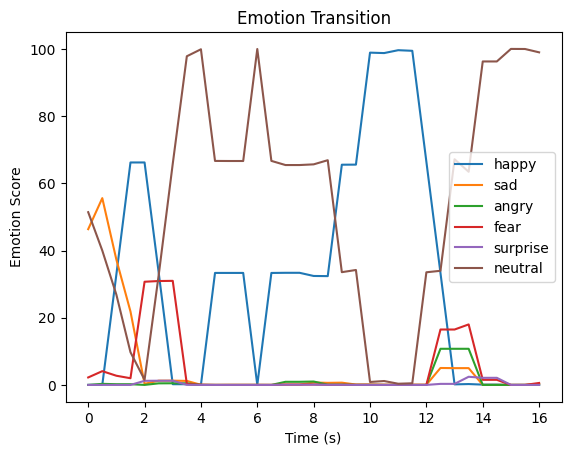

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("emotion_log_detail.csv")

# 移動平均（3点）
df_smooth = df.copy()
for col in ["happy", "sad", "angry", "fear", "surprise", "neutral"]:
    df_smooth[col] = df[col].rolling(window=3, min_periods=1).mean()

# グラフ
plt.figure()

for col in ["happy", "sad", "angry", "fear", "surprise", "neutral"]:
    plt.plot(df_smooth["time"], df_smooth[col], label=col)

plt.xlabel("Time (s)")
plt.ylabel("Emotion Score")
plt.legend()
plt.title("Emotion Transition")

plt.show()